In [162]:
%load_ext autoreload
%autoreload 2

import numpy as np
import polars as pl
import torch
import torch_geometric as pyg
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
import matplotlib.pyplot as plt

from bipartite_gnn.graph_visualizatons import visualize_graph, visualize_embeddings
from baseline_evals.feature_selection import variance_filtering, class_variational_selection
from bipartite_gnn.preprocessing import mrmr_selection
from baseline_evals.knn_eval import knn_eval
from baseline_evals.svm_eval import svm_eval
from baseline_evals.xgboost_eval import xgboost_eval
from baseline_evals.mlp_eval import mlp_eval
from gnn_experiments.mogonet_eval import mogonet_eval

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [156]:
mrna = pl.read_csv('MDS_data_preprocessed/mrna.csv')
mirna = pl.read_csv('MDS_data_preprocessed/mirna.csv')
circrna = pl.read_csv('MDS_data_preprocessed/circrna.csv')
te_counts = pl.read_csv('MDS_data_preprocessed/te_counts.csv')
pirna = pl.read_csv('MDS_data_preprocessed/pirna.csv')

annot = pl.read_csv('MDS_data_preprocessed/annotations.csv')

In [148]:
sample_names = annot['SAMPLE_NAME'].to_list()
sample_names = [name.split('_')[0] for name in sample_names]

pirna_sample_names = pirna.columns[1:]

all_common_sample_names = list(set(pirna_sample_names).intersection(set(sample_names)))

In [163]:
mrna_s = mrna.select(['GENE_NAME'] + all_common_sample_names)
mirna_s = mirna.select(['GENE_NAME'] + all_common_sample_names)
circrna_s = circrna.select(['circRNA_ID'] + all_common_sample_names)
te_counts_s = te_counts.select(['TE'] + all_common_sample_names)

annot_s = annot.filter(pl.col('sample_ids').is_in(all_common_sample_names))

In [164]:
y_d = annot_s['1 disease'].to_numpy()
y_r = annot_s['2 risk'].to_numpy()
y_m = annot_s['3 mutations (SF3B1only_wt)'].to_numpy()

y = y_d - 1

select_samples = y != -1

np.unique(y_d, return_counts=True), np.unique(y_r, return_counts=True), np.unique(y_m, return_counts=True)

((array([1, 2]), array([ 7, 59])),
 (array([0, 1, 2]), array([15, 27, 24])),
 (array([0, 1, 2]), array([41, 13, 12])))

In [157]:
y_d = annot['1 disease'].to_numpy()
y_r = annot['2 risk'].to_numpy()
y_m = annot['3 mutations (SF3B1only_wt)'].to_numpy()

y = y_d - 1

select_samples = y != -1

np.unique(y_d, return_counts=True), np.unique(y_r, return_counts=True), np.unique(y_m, return_counts=True)

((array([1, 2]), array([13, 61])),
 (array([0, 1, 2]), array([21, 29, 24])),
 (array([0, 1, 2]), array([48, 14, 12])))

In [165]:
# mrna_X = mrna.to_numpy()[:, 1:].T
# mirna_X = mirna.to_numpy()[:, 1:].T
# circrna_X = circrna.to_numpy()[:, 1:].T
# te_counts_X = te_counts.to_numpy()[:, 1:].T
# pirna_X = pirna.to_numpy()[:, 1:].T

mrna_X = mrna_s.to_numpy()[:, 1:].T
mirna_X = mirna_s.to_numpy()[:, 1:].T
circrna_X = circrna_s.to_numpy()[:, 1:].T
te_counts_X = te_counts_s.to_numpy()[:, 1:].T
pirna_X = pirna.to_numpy()[:, 1:].T

mrna_X = mrna_X[select_samples]
mirna_X = mirna_X[select_samples]
circrna_X = circrna_X[select_samples]
te_counts_X = te_counts_X[select_samples]
# pirna_X = pirna_X[select_samples]

y = y[select_samples]

X = np.hstack([mrna_X, mirna_X])

In [140]:
knn_eval(X, y, select_n_features=True, nn_range=(1, 15))
svm_eval(X, y, select_n_features=True, verbose=False, n_trials=25)
xgboost_eval(X, y, verbose=False, n_trials=25)
# mlp_eval(X, y, n_trials=1, reg_type="l1", n_evals=5)

500
| KNN | 0.91 +/- 0.03 | 0.54 +/- 0.13 | 0.87 +/- 0.04 |
study.best_value=0.8723197961458832, study.best_params={'n_neighbors': 3, 'n_features': 1390}
| LIN SVM | 0.68 +/- 0.03 | 0.49 +/- 0.07 | 0.73 +/- 0.02 |
study.best_value=0.7327956254272043, study.best_params={'C': 1.1469376692870648, 'class_weight': 'balanced', 'n_features': 1206}


KeyboardInterrupt: 

In [143]:
xgboost_eval(X, y, verbose=True, n_trials=25)

0 / 25
 XGBoost val | 0.77 +/- 0.14 | 0.50 +/- 0.15 | 0.74 +/- 0.10 |
| XGBoost | 0.85 +/- 0.05 | 0.51 +/- 0.10 | 0.83 +/- 0.03 |
1 / 25
 XGBoost val | 0.84 +/- 0.01 | 0.52 +/- 0.13 | 0.78 +/- 0.04 |
| XGBoost | 0.86 +/- 0.06 | 0.51 +/- 0.10 | 0.84 +/- 0.04 |
2 / 25
3 / 25
Pruning trial
4 / 25
5 / 25
Pruning trial
6 / 25
7 / 25
 XGBoost val | 0.84 +/- 0.01 | 0.46 +/- 0.00 | 0.76 +/- 0.01 |
| XGBoost | 0.89 +/- 0.04 | 0.47 +/- 0.01 | 0.85 +/- 0.05 |
8 / 25
9 / 25
Pruning trial
10 / 25
Pruning trial
11 / 25
12 / 25
13 / 25
Pruning trial
14 / 25
15 / 25
16 / 25
17 / 25
18 / 25
 XGBoost val | 0.87 +/- 0.06 | 0.57 +/- 0.22 | 0.81 +/- 0.09 |
| XGBoost | 0.91 +/- 0.03 | 0.54 +/- 0.13 | 0.87 +/- 0.04 |
19 / 25
20 / 25
21 / 25
22 / 25
Pruning trial
23 / 25
24 / 25
Pruning trial
| XGBoost | 0.91 +/- 0.03 | 0.54 +/- 0.13 | 0.87 +/- 0.04 |
study.best_value=0.8723197961458832, study.best_params={'booster': 'gblinear', 'lambda': 0.0011645317947923993, 'alpha': 0.09869475948154756}


{'acc': 0.90989010989011,
 'f1_macro': 0.5426265328874025,
 'f1_weighted': 0.8723197961458832,
 'acc_std': 0.026373626373626412,
 'f1_macro_std': 0.13467377672791955,
 'f1_weighted_std': 0.041766013284268745,
 'acc_val': 0.8714285714285716,
 'acc_val_std': 0.0649437223665993,
 'f1_macro_val': 0.565034965034965,
 'f1_macro_val_std': 0.21749938099349655,
 'f1_weighted_val': 0.8127872127872127,
 'f1_weighted_val_std': 0.09450838093364636}

In [161]:
a = "GENE_NAME,V888,V108,V2089,V1279,V1090,V777,N85,V839,V1565,V637,V1505,V1834,V67,V1441,V1920,V1857,V630,V456,N84,N60,V1394,V1048,V18,N83,V538,V1742,V1884,V1297,V125,V1921,V1776,V1860,V940,N82,V148,V1456,V2092,V714,V1337,V553,V406,V1788,V2133,V1874,V221,N58,V1591,V2110,V574,V716,N70,V1321,V1800,V806,V513,V1592,V1528,V1823,V344,V1708,V359,V712,V883,V655,V1699,V624"
len(a.split(','))

67

In [167]:
val, test = mogonet_eval(
    n_splits=3,
    input_omics={
        "mrna": mrna,
        "mirna": mirna,
        "circrna": circrna,
        # "te_counts": te_counts,
        # "pirna": pirna,
    },
    n_input_features={
        "mrna": 200,
        "mirna": 200,
        "circrna": 69,
        # "pirna": 200,
        # "te_counts": 200,
    },
    mrmr_selection_params={
         'mrmr_path' : "MDS_data_preprocessed/mrmr_selected/mutation",
    },
    y=y,
    params={
        "encoder_hidden_channels": {
            "mrna": 50,
            "circrna": 50,
            "pirna": 50,
            "mirna": 50,
            "te_counts": 50,
        },
        "encoder_type": "gat",
        "num_classes": 2,
        "graph_style": "threshold",
        "avg_degree": 10,
        # "graph_style": "knn",
        # "knn": 10,
        "dropout": 0.1,
        "epochs": 400,
        "log_interval": 50,
        "save_best_model": True,
        "best_model_path" : 'disease_mogonet_model.pth',
        "integrator_type": "attention",
        "integration_dim": 2,
        "self_connections": True,
    }
)

print(f"| MOGONET GAT (mirna only) val | {val[:, 0].mean():.2f} +/- {val[:, 0].std():.2f} | {val[:, 1].mean():.2f} +/- {val[:, 1].std():.2f} | {val[:, 2].mean():.2f} +/- {val[:, 2].std():.2f} |")
print(f"| MOGONET GAT (mirna only) test | {test[:, 0].mean():.2f} +/- {test[:, 0].std():.2f} | {test[:, 1].mean():.2f} +/- {test[:, 1].std():.2f} | {test[:, 2].mean():.2f} +/- {test[:, 2].std():.2f} |")

Fold 1 / 3
Loading MDS_data_preprocessed/mrmr_selected/mutation/mrna/mrna_fold_0.csv
Loading MDS_data_preprocessed/mrmr_selected/mutation/mirna/mirna_fold_0.csv
Loading MDS_data_preprocessed/mrmr_selected/mutation/circrna/circrna_fold_0.csv
Saving on epoch 1
Epoch: 050:
Train Loss: 0.2385, Train Acc: 0.9091, Train F1 Macro: 0.8301, Train F1 Weighted: 0.9196
Val Loss: 0.7649, Val Acc: 0.7273, Val F1 Macro: 0.4211, Val F1 Weighted: 0.7656
Test Loss: 0.9461, Test Acc: 0.4545, Test F1 Macro: 0.3125, Test F1 Weighted: 0.5682
##################################################
Epoch: 100:
Train Loss: 0.0168, Train Acc: 1.0000, Train F1 Macro: 1.0000, Train F1 Weighted: 1.0000
Val Loss: 1.5294, Val Acc: 0.8182, Val F1 Macro: 0.4500, Val F1 Weighted: 0.8182
Test Loss: 1.7742, Test Acc: 0.8182, Test F1 Macro: 0.4500, Test F1 Weighted: 0.8182
##################################################
Epoch: 150:
Train Loss: 0.0221, Train Acc: 0.9773, Train F1 Macro: 0.9481, Train F1 Weighted: 0.9782
Val 

In [168]:
y

array([1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
feature_importances = {
    "mrna": {},
    "mirna": {},
    "circrna": {},
}

skf = StratifiedKFold(n_splits=3)

i = 0

for train_idx, test_idx in skf.split(np.zeros(len(y)), y):
    
    print(f"Fold {i}")

    omics = {}
    feature_names = {}

    mrna = pl.read_csv(f"MDS_data_preprocessed/mrmr_selected/disease/mrna/mrna_fold_{i}.csv")
    mirna = pl.read_csv(f"MDS_data_preprocessed/mrmr_selected/disease/mirna/mirna_fold_{i}.csv")
    circrna = pl.read_csv(f"MDS_data_preprocessed/mrmr_selected/disease/circrna/circrna_fold_{i}.csv")

    print(mrna)
    print(mirna)
    print(circrna)

    omics["mrna"] = mrna[:, 1:].to_numpy().T
    omics["circrna"] = circrna[:, 1:].to_numpy().T
    omics["mirna"] = mirna[:, 1:].to_numpy().T

    feature_names["mrna"] = mrna["GENE_NAME"].to_list()
    feature_names["circrna"] = circrna["GENE_NAME"].to_list()
    feature_names["mirna"] = mirna["circRNA_ID"].to_list()

    graph_style="threshold"
    avg_degree=10
    self_connections=True

    data = pyg.data.HeteroData()

    data.test_mask = test_idx

    data.y = y

    for omic in omics.keys():

        mms = StandardScaler()
        mms.fit(omics[omic][train_idx])
        omics[omic] = torch.tensor(mms.transform(omics[omic]), dtype=torch.float32)

        A_cos_sim = cosine_similarity_matrix(omics[omic])
 
        A = threshold_matrix(
            A_cos_sim,
            self_connections=self_connections,
            target_avg_degree=avg_degree,
        )

        data[omic].x = omics[omic]
        data[omic].edge_index = dense_to_coo(A)

    model = MOGONET(
        omics=data.x_dict.keys(),
        in_channels=[data.x_dict[omics].shape[1] for omics in data.x_dict.keys()],
        hidden_channels={
            "mrna": 200,
            "mirna": 200,
            # "cna": 200,
            "circrna": 200,
        },
        encoder_type="gat",
        num_classes=2,
        dropout=0.05,
        integrator_type="attention",
        integration_dim=4,
    )

    model.load_state_dict(torch.load(f"fold_{i}_mogonet_model.pth"))

    model.eval()

    feature_importances = model.get_feature_importances(data, feature_names, feature_importances)
    
    i += 1

- risk, mrna, mirna, circrna, pirna, te_counts

| MOGONET GAT all | 0.80 +/- 0.00 | 0.78 +/- 0.02 | 0.79 +/- 0.01 |
| MOGONET GAT omics | 0.82 +/- 0.18 | 0.82 +/- 0.19 | 0.82 +/- 0.18 |

- mutation, mrna, mirna, circrna, pirna, te_counts

| MOGONET GAT (mirna only) val | 0.80 +/- 0.27 | 0.73 +/- 0.37 | 0.73 +/- 0.37 |
| MOGONET GAT (mirna only) test | 0.93 +/- 0.15 | 0.93 +/- 0.15 | 0.93 +/- 0.15 |

# disease
mrna
    800 features
    2.0 multiplier
    dropout 0.1
    attention dropout 0.1
    2 layers
    no projection layer
    1e-4 lr, 5e-4 weight decay
    weights 70, 70, 50, 30

    

In [263]:
pirna

piRNA,V1505,N83,V513,N85,V630,V655,V883,V1279,V344,V456,V1860,V839,N60,V1776,V1742,N70,V1921,V553,V888,V940,V1884,N82,V2092,N58,V148,V777,V2110,V1394,V406,V2089,V1565,V1823,V806,V67,V1857,V714,V221,V1337,V1456,V1297,N84,V1090,V1788,V1708,V2133,V1699,V1048,V18,V1321,V1591,V538,V1441,V1592,V1920,V125,V1800,V574,V624,V108,V712,V1834,V637,V1528,V1874,V716,V359
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""hsa_piR_016899…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,331,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""hsa_piR_020391…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,34,0,0,0,0,0,0,0,0,0,0,0,0,0,35,0,0,0,0,0,0,0,0,0,0,0,0,0,45,0,0,149,0,0,0,0,0,0,0,0,73,0,0,0,0,0,0,24,0,18
"""hsa_piR_001840…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,19,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11,0,0,381,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,85,0,0,0,0,0,0,0,0,0
"""hsa_piR_003239…",0,0,0,12,0,254,0,0,0,0,0,0,0,0,0,0,0,26,0,0,0,23,0,0,0,0,0,0,0,0,17,0,0,0,120,20,0,0,0,0,18,0,0,0,49,0,0,0,0,0,0,0,0,0,0,0,0,0,0,12,0,0,24,0,0,0
"""hsa_piR_009903…",0,0,0,10,0,0,0,0,0,12,0,0,0,11,0,0,0,0,11,49,0,10,0,0,11,0,17,14,0,0,0,0,0,0,1108,0,0,0,0,0,10,0,0,0,0,0,11,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,14,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""hsa_piR_020814…",193,277,114,274,226,176,130,111,93,158,87,18,133,128,122,203,168,47,111,45,94,275,67,274,138,160,222,418,147,175,315,88,92,210,573,515,157,103,79,225,115,157,154,246,94,108,50,309,170,70,163,177,327,127,143,319,50,60,176,204,214,14,144,230,93,93
"""hsa_piR_020815…",389,307,365,316,256,937,92,214,132,513,250,104,132,187,289,225,170,218,339,265,170,450,126,458,291,422,231,1005,74,183,316,117,225,509,137,210,625,82,177,157,310,417,266,551,77,201,270,604,1068,314,482,340,578,131,466,458,120,223,503,735,669,12,329,493,555,304
"""hsa_piR_020829…",1198,823,1118,535,668,1421,613,373,1062,175,777,226,589,375,901,472,1493,823,1595,632,665,1131,573,1064,1735,610,1170,492,565,921,2732,506,765,852,766,2428,862,417,610,383,681,283,894,385,380,1050,544,3829,193,1241,412,65,475,138,1266,292,1242,380,600,323,687,146,1173,1346,215,985


In [2]:
circrna

NameError: name 'circrna' is not defined

In [105]:
mirna

GENE_NAME,V1884,N58,V630,N60,V1297,NV1428,N82,V940,V2092,V624,V777,V553,V1441,V1921,V538,V1857,V456,NV912,V2089,V1823,V2241,N54,V655,V2110,V839,V125,N83,V637,V712,NV911,V2133,V1742,V1591,V108,V1874,V221,V148,N70,N87,V574,V359,V1337,V883,V1592,V1422,V1708,V1505,V18,V1788,V1776,N84,V1800,V716,N86,V888,V1321,V1279,V1528,V344,N85,V1699,V1456,V1394,V714,V67,V1090,V1860,V406,V1834,V1048,V806,V513,V1565,V1920
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""MIR4802""",2,1,11,1,3,6,3,3,0,13,0,22,4,1,3,2,2,3,0,4,4,3,2,0,5,6,1,0,0,4,7,7,1,5,1,1,1,0,0,4,3,3,2,0,2,2,0,5,0,3,3,3,0,2,3,4,4,2,0,3,2,9,4,2,1,0,0,4,11,2,3,1,4,0
"""MIR4751""",1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
"""MIR378A""",6,3,5,3,2,4,4,1,1,10,5,12,5,4,1,9,4,1,4,2,4,9,4,7,1,7,1,6,12,3,4,5,0,7,9,3,4,1,9,3,8,5,2,11,5,1,2,2,6,10,3,5,0,0,4,5,10,0,1,2,5,4,5,7,6,7,5,8,11,2,11,1,7,10
"""MIR578""",0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0
"""MIR32""",22,10,9,16,14,14,11,13,4,4,10,22,1,11,13,6,12,10,2,4,11,12,5,6,28,16,13,3,12,4,0,8,10,15,14,5,6,10,8,4,8,11,8,10,24,18,11,10,5,4,14,5,9,6,13,6,12,16,11,5,17,9,10,12,7,7,8,16,13,8,5,11,10,13
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""MIR3187""",19,28,20,33,13,15,9,19,12,7,0,15,47,28,14,9,4,26,46,10,17,7,32,22,19,48,9,6,23,22,9,42,16,9,8,24,22,10,37,6,23,11,7,11,9,70,11,31,28,20,24,4,21,20,45,9,29,8,61,28,41,38,4,10,26,14,36,34,6,9,7,8,9,9
"""MIR4692""",1,0,0,1,0,0,0,0,2,0,0,2,0,0,0,2,0,0,0,0,0,0,0,1,7,0,0,0,1,0,2,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,2,0,3,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,1
"""MIR4270""",2,0,0,0,0,0,0,0,1,0,0,1,1,0,0,2,0,0,0,0,0,2,0,0,0,0,1,0,0,0,1,2,0,0,2,2,0,0,0,0,2,0,1,0,2,0,0,0,0,0,0,0,0,0,0,2,2,0,0,0,2,0,0,1,0,0,0,2,1,0,0,2,0,2


In [131]:
from gnn_experiments.bipartite_eval import bipartite_eval

val, test = bipartite_eval(
    n_splits=5,
    input_omics={
        "mrna": mrna,
        # "mirna": mirna,
        # # "circrna": circrna,
        # # "pirna": pirna,
        # "te_counts": te_counts,
    },
    n_input_features={
        "mrna": 200,
        # "mirna": 200,
        # # "circrna": 69,
        # # "pirna": 200,
        # "te_counts": 200,
    },
    multipliers={
        "mrna": 1.5,
        # "mirna": 2.0,
        # # "circrna": 1.0,
        # # "pirna": 1.5,
        # "te_counts": 2.0,
    },
    mrmr_selection_params={
        "mrmr_path": "MDS_data_preprocessed/mrmr_selected/mutation",
    },
    # mrmr_selection_params=None,
    input_omics_interactions={
        ("mrna", "mrna") : {
            "gene_interaction" : {
                "interactant_col_1" : "Official Symbol Interactor A",
                "interactant_col_2" : "Official Symbol Interactor B",
                "interactions_file" : "biogrid_preprocessed_data.csv",
            },
            "protein_interaction" : {
                "interactant_col_1" : "gene1",
                "interactant_col_2" : "gene2",
                "interactions_file" : "string_db/ppi.csv",
            },
        },
        # ("mrna", "mirna") : {
        #     "gene_interaction" : {
        #         "interactant_col_1" : "gene",
        #         "interactant_col_2" : "mirna_gene",
        #         "interactions_file" : "MDS_data_preprocessed/mirna_mrna_interactions_mds.csv",
        #     },
        # },
    },
    y=y,
    params={
        "epochs": 200,
        "log_interval": 25,
        "save_best_model": False,
        "best_model_path": "mutation_bipartite_gnn.pth",
        "l1_lambda": 0.0,
        "hidden_channels": [200, 50, 50, 2, 10],
        "heads": 4,
        "dropout": 0.05,
        "attention_dropout": 0.05,
        "integrator_type": "attention",
        "three_layers": True,
        "proj_dim": 200,
        "use_proj_module": False,
    }
)

print(val)
print(test)

print("BipartiteGNN (mrna) results:")
print(f"| BipartiteGNN val | {val[:, 0].mean():.2f} +/- {val[:, 0].std():.2f} | {val[:, 1].mean():.2f} +/- {val[:, 1].std():.2f} | {val[:, 2].mean():.2f} +/- {val[:, 2].std():.2f} |")
print(f"| BipartiteGNN test | {test[:, 0].mean():.2f} +/- {test[:, 0].std():.2f} | {test[:, 1].mean():.2f} +/- {test[:, 1].std():.2f} | {test[:, 2].mean():.2f} +/- {test[:, 2].std():.2f} |")

dict_keys(['mrna'])
Fold 1 / 5
Projection dimension: 200
torch.Size([200]) torch.Size([200])
isolated sample nodes, isolated gene nodes, mean degree: 
tensor(1) tensor(0) tensor(20.9091)
Found 313.0 interactions
Found 272.0 interactions
HeteroData(
  omics=[1],
  feature_names=[1],
  y=[26],
  train_mask=[20],
  val_mask=[3],
  test_mask=[3],
  num_relations=3,
  mrna={ x=[66, 200] },
  mrna_feature={ x=[200, 200] },
  (mrna, diff_exp, mrna_feature)={
    edge_index=[2, 1380],
    edge_attr=[1380, 1],
  },
  (mrna_feature, interacts, mrna_feature)={ edge_index=[2, 722] },
  (mrna_feature, rev_diff_exp, mrna)={
    edge_index=[2, 1380],
    edge_attr=[1380, 1],
  }
)
relations [('mrna', 'diff_exp', 'mrna_feature'), ('mrna_feature', 'interacts', 'mrna_feature'), ('mrna_feature', 'rev_diff_exp', 'mrna')]
Epoch: 025:
Train Loss: 0.3376, Train Acc: 1.0000, Train F1 Macro: 1.0000, Train F1 Weighted: 1.0000
Val Loss: 0.6650, Val Acc: 0.6667, Val F1 Macro: 0.6667, Val F1 Weighted: 0.6667
Test 

In [128]:
feature_importances = {
    "mrna" : {},
    "mirna" : {},
    "te_counts": {},
}

In [130]:
from gnn_experiments.bipartite_gnn import BiRGAT

In [ ]:
fold = 0

skf = StratifiedKFold(n_splits=5)

feature_importances = [None] * 5

for train_idx, test_idx in skf.split(np.zeros(len(y)), y):

    graph_style="threshold"
    avg_degree=8
    self_connections=True

    data = pyg.data.HeteroData()

    data.test_mask = test_idx
    data.y = y

    model = BiRGAT(
        
    )

    model.load_state_dict(torch.load(f"fold_{fold}_mogonet_model.pth"))

    model.eval()

    feature_importances = model.get_feature_importances(data, feature_names)

    fold += 1

    break

- risk, mrna, mirna, pirna

| BipartiteGNN val | 0.84 +/- 0.17 | 0.79 +/- 0.26 | 0.81 +/- 0.23 |  
| BipartiteGNN test | 0.85 +/- 0.08 | 0.84 +/- 0.10 | 0.84 +/- 0.09 |

- mutation mrna, mirna, te_counts
note: this is not very stable, probably due to the small number of samples

| BipartiteGNN val | 1.00 +/- 0.00 | 1.00 +/- 0.00 | 1.00 +/- 0.00 |
| BipartiteGNN test | 0.87 +/- 0.18 | 0.87 +/- 0.18 | 0.87 +/- 0.18 |
middle ground | BipartiteGNN | 0.94 +/- 0.09 | 0.94 +/- 0.09 | 0.94 +/- 0.09 |

### mutation mrna only
| Model | ACC | F1 macro | F1 weighted |
| --- | --- | --- | --- |
| KNN | 0.80 +/- 0.22 | 0.76 +/- 0.26 | 0.76 +/- 0.28 |
| LIN SVM | 0.92 +/- 0.10 | 0.90 +/- 0.12 | 0.91 +/- 0.11 |
| XGBoost | 0.92 +/- 0.10 | 0.90 +/- 0.12 | 0.91 +/- 0.11 |
| MOGONET GAT | 0.87 +/- 0.18 | 0.76 +/- 0.33 | 0.81 +/- 0.26 |
| BipartiteGNN | 0.70 +/- 0.27 | 0.60 +/- 0.37 | 0.60 +/- 0.37 |

### mutation mirna only
| Model | ACC | F1 macro | F1 weighted |
| --- | --- | --- | --- |
| KNN | 0.88 +/- 0.16 | 0.87 +/- 0.17 | 0.87 +/- 0.17 |
| LIN SVM | 0.88 +/- 0.24 | 0.86 +/- 0.29 | 0.87 +/- 0.26 |
| XGBoost | 0.92 +/- 0.16 | 0.92 +/- 0.17 | 0.92 +/- 0.16 |
| MLP regularization : None | 0.50 +/- 0.35 | 0.47 +/- 0.38 | 0.47 +/- 0.38 |
| MOGONET GAT | 0.80 +/- 0.27 | 0.73 +/- 0.37 | 0.73 +/- 0.37 |
| BipartiteGNN | 0.73 +/- 0.28 | 0.66 +/- 0.34 | 0.71 +/- 0.29 |

### mutation circrna only
| Model | ACC | F1 macro | F1 weighted |
| --- | --- | --- | --- |
| KNN | 0.84 +/- 0.15 | 0.82 +/- 0.16 | 0.83 +/- 0.16 |
| LIN SVM | 0.84 +/- 0.08 | 0.82 +/- 0.09 | 0.83 +/- 0.08 |
| XGBoost | 0.88 +/- 0.10 | 0.86 +/- 0.11 | 0.87 +/- 0.10 |
| MLP regularization : None | 0.78 +/- 0.16 | 0.77 +/- 0.17 | 0.78 +/- 0.17 |
| MOGONET GAT | 0.60 +/- 0.28 | 0.46 +/- 0.31 | 0.55 +/- 0.27 |
| BipartiteGNN | 0.80 +/- 0.30 | 0.78 +/- 0.33 | 0.77 +/- 0.37 |

### mutation pirna only
| Model | ACC | F1 macro | F1 weighted |
| --- | --- | --- | --- |
| KNN | 0.64 +/- 0.15 | 0.55 +/- 0.20 | 0.56 +/- 0.21 |
| LIN SVM | 0.68 +/- 0.10 | 0.66 +/- 0.10 | 0.68 +/- 0.09 |
| XGBoost | 0.72 +/- 0.10 | 0.66 +/- 0.16 | 0.68 +/- 0.14 |
| MLP regularization : None | 0.62 +/- 0.10 | 0.55 +/- 0.16 | 0.56 +/- 0.17 |
| MOGONET GAT test | 0.60 +/- 0.28 | 0.57 +/- 0.32 | 0.57 +/- 0.32 |
| BipartiteGNN test | 0.67 +/- 0.33 | 0.58 +/- 0.39 | 0.61 +/- 0.38 |

### mutation te counts only
| Model | ACC | F1 macro | F1 weighted |
| --- | --- | --- | --- |
| KNN | 0.76 +/- 0.08 | 0.76 +/- 0.09 | 0.75 +/- 0.09 |
| LIN SVM | 0.84 +/- 0.15 | 0.84 +/- 0.16 | 0.83 +/- 0.16 |
| XGBoost | 0.84 +/- 0.15 | 0.84 +/- 0.16 | 0.83 +/- 0.16 |
| MLP regularization : l1 | 0.47 +/- 0.16 | 0.36 +/- 0.16 | 0.34 +/- 0.22 |
| MOGONET GAT (mirna only) val | 0.70 +/- 0.45 | 0.67 +/- 0.47 | 0.67 +/- 0.47 |
| BipartiteGNN test | 0.73 +/- 0.28 | 0.66 +/- 0.34 | 0.71 +/- 0.29 |


### combinations

### risk mrna only

| Model | ACC | F1 macro | F1 weighted |
| --- | --- | --- | --- |
| KNN | 0.73 +/- 0.09 | 0.69 +/- 0.11 | 0.70 +/- 0.10 |
| LIN SVM | 0.79 +/- 0.09 | 0.76 +/- 0.12 | 0.77 +/- 0.11 |
| XGBoost | 0.73 +/- 0.12 | 0.69 +/- 0.15 | 0.70 +/- 0.14 |
| MLP regularization : None | 0.70 +/- 0.19 | 0.69 +/- 0.20 | 0.70 +/- 0.20 |
| MOGONET GAT (mirna only) test | 0.67 +/- 0.29 | 0.64 +/- 0.31 | 0.65 +/- 0.31 |
| BipartiteGNN test | 0.69 +/- 0.12 | 0.63 +/- 0.19 | 0.65 +/- 0.16 |

### risk mirna only
| Model | ACC | F1 macro | F1 weighted |
| --- | --- | --- | --- |
| KNN | 0.69 +/- 0.19 | 0.66 +/- 0.20 | 0.67 +/- 0.20 |
| LIN SVM | 0.67 +/- 0.08 | 0.64 +/- 0.09 | 0.65 +/- 0.09 |
| XGBoost | 0.67 +/- 0.09 | 0.66 +/- 0.09 | 0.67 +/- 0.09 |
| MLP regularization : None | 0.48 +/- 0.14 | 0.44 +/- 0.11 | 0.46 +/- 0.11 |
| MOGONET GAT (mirna only) val | 0.65 +/- 0.14 | 0.62 +/- 0.22 | 0.68 +/- 0.20 |
| BipartiteGNN test | 0.77 +/- 0.09 | 0.71 +/- 0.19 | 0.73 +/- 0.16 |


### risk circrna only
| Model | ACC | F1 macro | F1 weighted |
| --- | --- | --- | --- |
| KNN | 0.63 +/- 0.14 | 0.61 +/- 0.14 | 0.62 +/- 0.13 |
| LIN SVM | 0.71 +/- 0.06 | 0.70 +/- 0.07 | 0.70 +/- 0.07 |
| XGBoost | 0.73 +/- 0.07 | 0.72 +/- 0.08 | 0.72 +/- 0.08 |
| MLP regularization : None | 0.52 +/- 0.14 | 0.48 +/- 0.17 | 0.50 +/- 0.16 |
| MOGONET GAT (mirna only) test | 0.69 +/- 0.30 | 0.65 +/- 0.36 | 0.65 +/- 0.36 |
| BipartiteGNN val | 0.66 +/- 0.17 | 0.65 +/- 0.17 | 0.64 +/- 0.18 |


### risk pirna only
| Model | ACC | F1 macro | F1 weighted |
| --- | --- | --- | --- |
| KNN | 0.65 +/- 0.15 | 0.61 +/- 0.17 | 0.62 +/- 0.17 |
| LIN SVM | 0.55 +/- 0.14 | 0.55 +/- 0.14 | 0.55 +/- 0.14 |
| XGBoost | 0.59 +/- 0.16 | 0.58 +/- 0.17 | 0.58 +/- 0.16 |
| MLP regularization : None | 0.33 +/- 0.16 | 0.32 +/- 0.16 | 0.33 +/- 0.16 |
| MOGONET GAT (mirna only) test | 0.69 +/- 0.23 | 0.68 +/- 0.24 | 0.68 +/- 0.24 |
| BipartiteGNN test | 0.69 +/- 0.22 | 0.67 +/- 0.27 | 0.68 +/- 0.24 |

### risk te counts only
| Model | ACC | F1 macro | F1 weighted |
| --- | --- | --- | --- |
| KNN | 0.66 +/- 0.09 | 0.61 +/- 0.14 | 0.62 +/- 0.12 |
| LIN SVM | 0.60 +/- 0.12 | 0.59 +/- 0.13 | 0.58 +/- 0.13 |
| XGBoost | 0.73 +/- 0.11 | 0.71 +/- 0.13 | 0.72 +/- 0.12 |
| MLP regularization : None | 0.41 +/- 0.05 | 0.37 +/- 0.09 | 0.36 +/- 0.10 |
| MOGONET GAT (mirna only) test | 0.65 +/- 0.17 | 0.64 +/- 0.17 | 0.64 +/- 0.17 |
| BipartiteGNN test | 0.61 +/- 0.25 | 0.54 +/- 0.26 | 0.57 +/- 0.25 |

### risk combinations

### disease mrna only

| Model | ACC | F1 macro | F1 weighted |
| --- | --- | --- | --- |
| KNN | 0.89 +/- 0.11 | 0.75 +/- 0.26 | 0.88 +/- 0.13 |
| LIN SVM | 0.85 +/- 0.13 | 0.80 +/- 0.14 | 0.86 +/- 0.12 |
| XGBoost | 0.95 +/- 0.03 | 0.90 +/- 0.06 | 0.94 +/- 0.03 |
| MLP | 0.90 +/- 0.09 | 0.79 +/- 0.20 | 0.89 +/- 0.10 |
| MogonetGAT | 0.95 +/- 0.07 | 0.86 +/- 0.23 | 0.94 +/- 0.09 |
| BipartiteGNN | 0.93 +/- 0.11 | 0.89 +/- 0.15 | 0.93 +/- 0.10 |

### disease mirna only

| Model | ACC | F1 macro | F1 weighted |
| --- | --- | --- | --- |
| KNN | 0.88 +/- 0.02 | 0.70 +/- 0.12 | 0.85 +/- 0.04 |
| LIN SVM | 0.77 +/- 0.12 | 0.68 +/- 0.18 | 0.79 +/- 0.11 |
| XGBoost | 0.91 +/- 0.05 | 0.79 +/- 0.18 | 0.89 +/- 0.07 |
| MLP regularization : None | 0.80 +/- 0.17 | 0.69 +/- 0.21 | 0.80 +/- 0.16 |
| MOGONET GAT | 0.95 +/- 0.07 | 0.86 +/- 0.23 | 0.94 +/- 0.09 |
| BipartiteGNN | 0.93 +/- 0.07 | 0.81 +/- 0.22 | 0.91 +/- 0.09 |

### disease circrna

| Model | ACC | F1 macro | F1 weighted |
| --- | --- | --- | --- |
| KNN | 0.84 +/- 0.05 | 0.65 +/- 0.11 | 0.82 +/- 0.05 |
| LIN SVM | 0.85 +/- 0.08 | 0.79 +/- 0.06 | 0.86 +/- 0.07 |
| XGBoost | 0.85 +/- 0.06 | 0.70 +/- 0.13 | 0.84 +/- 0.06 |
| MLP regularization : None | 0.82 +/- 0.10 | 0.66 +/- 0.22 | 0.80 +/- 0.12 |
| MOGONET GAT (mirna only) test | 0.85 +/- 0.14 | 0.71 +/- 0.27 | 0.83 +/- 0.16 |
| BipartiteGNN val | 0.89 +/- 0.12 | 0.71 +/- 0.27 | 0.87 +/- 0.12 |

### diesease pirna

| Model | ACC | F1 macro | F1 weighted |
| --- | --- | --- | --- |
| KNN | 0.89 +/- 0.04 | 0.47 +/- 0.01 | 0.85 +/- 0.05 |
| LIN SVM | 0.80 +/- 0.06 | 0.44 +/- 0.02 | 0.79 +/- 0.05 |
| XGBoost | 0.89 +/- 0.04 | 0.47 +/- 0.01 | 0.85 +/- 0.05 |
| MLP regularization : None | 0.73 +/- 0.13 | 0.42 +/- 0.05 | 0.73 +/- 0.07 |
| MOGONET GAT (mrna only) test | 0.87 +/- 0.05 | 0.47 +/- 0.02 | 0.83 +/- 0.07 |
| BipartiteGNN test | 0.85 +/- 0.14 | 0.62 +/- 0.33 | 0.84 +/- 0.16 |


### disease te_counts
| Model | ACC | F1 macro | F1 weighted |
| --- | --- | --- | --- |
| KNN | 0.87 +/- 0.09 | 0.77 +/- 0.15 | 0.86 +/- 0.10 |
| LIN SVM | 0.88 +/- 0.08 | 0.77 +/- 0.18 | 0.87 +/- 0.08 |
| XGBoost | 0.93 +/- 0.04 | 0.82 +/- 0.18 | 0.92 +/- 0.06 |
| MLP regularization : None | 0.82 +/- 0.03 | 0.60 +/- 0.10 | 0.79 +/- 0.04 |
| MOGONET GAT (mrna only) val | 0.85 +/- 0.08 | 0.75 +/- 0.22 | 0.85 +/- 0.09 |
| BipartiteGNN val | 0.74 +/- 0.12 | 0.62 +/- 0.13 | 0.76 +/- 0.09 |


### disease integrating multiple omics
| Model | ACC | F1 macro | F1 weighted |
| --- | --- | --- | --- |
| KNN | 0.92 +/- 0.07 | 0.78 +/- 0.20 | 0.90 +/- 0.09 |
| LIN SVM | 0.84 +/- 0.14 | 0.79 +/- 0.15 | 0.85 +/- 0.13 |
| XGBoost (mrna, mirna, circrna) | 0.95 +/- 0.03 | 0.90 +/- 0.06 | 0.94 +/- 0.03 |
| MOGONET GAT (mrna, mirna, circrna) test | 0.98 +/- 0.06 | 0.97 +/- 0.07 | 0.98 +/- 0.05 |
| BipartiteGNN test (mrna, mirna) | 0.93 +/- 0.07 | 0.82 +/- 0.22 | 0.91 +/- 0.08 |


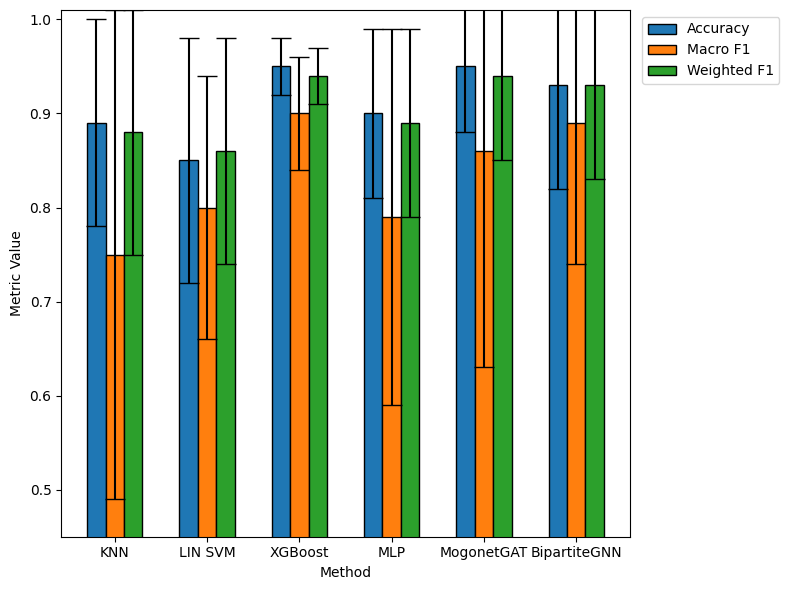

In [60]:
import matplotlib.pyplot as plt
import numpy as np

# Data
methods = ['KNN', 'LIN SVM', 'XGBoost', 'MLP', 'MogonetGAT', 'BipartiteGNN']

# disease mrna
accuracy = [0.89, 0.85, 0.95, 0.90, 0.95, 0.93]
accuracy_std = [0.11, 0.13, 0.03, 0.09, 0.07, 0.11]
macro_f1 = [0.75, 0.80, 0.90, 0.79, 0.86, 0.89]
macro_f1_std = [0.26, 0.14, 0.06, 0.20, 0.23, 0.15]
weighted_f1 = [0.88, 0.86, 0.94, 0.89, 0.94, 0.93]
weighted_f1_std = [0.13, 0.12, 0.03, 0.10, 0.09, 0.10]

# Figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Bar positions
bar_width = 0.2
r1 = np.arange(len(accuracy))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]

# Bars
bars1 = ax.bar(r1, accuracy, width=bar_width, edgecolor='black', capsize=7, yerr=accuracy_std, label='Accuracy')
bars2 = ax.bar(r2, macro_f1, width=bar_width, edgecolor='black', capsize=7, yerr=macro_f1_std, label='Macro F1')
bars3 = ax.bar(r3, weighted_f1, width=bar_width, edgecolor='black', capsize=7, yerr=weighted_f1_std, label='Weighted F1')

# X-axis labels
ax.set_xticks([r + bar_width for r in range(len(accuracy))], methods)
ax.set_xlabel('Method')

# Y-axis label
ax.set_ylabel('Metric Value')

# Legend
# ax.legend()
ax.legend(bbox_to_anchor=(1.01, 1.0), loc='upper left')

# Adjust layout
plt.tight_layout()

# make y axis start at 0.5
plt.ylim(0.45, 1.01)

# Show the plot
plt.savefig('disease graph.png')

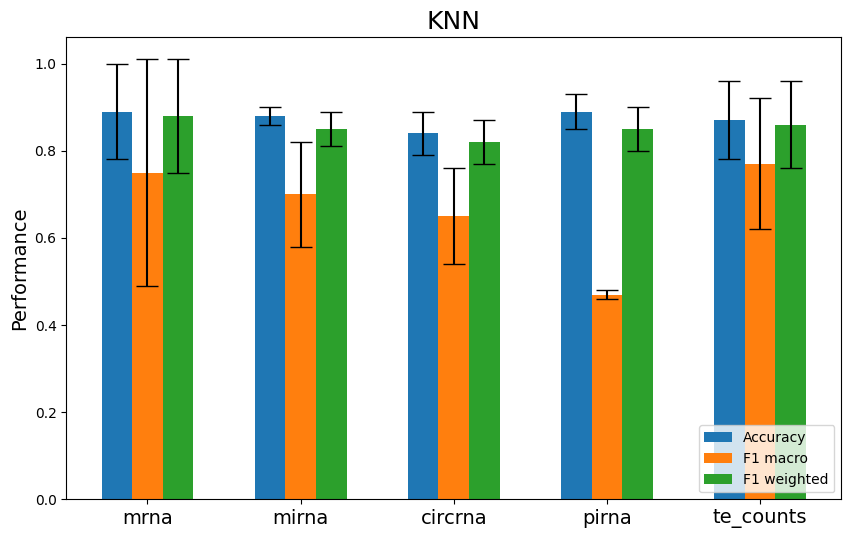

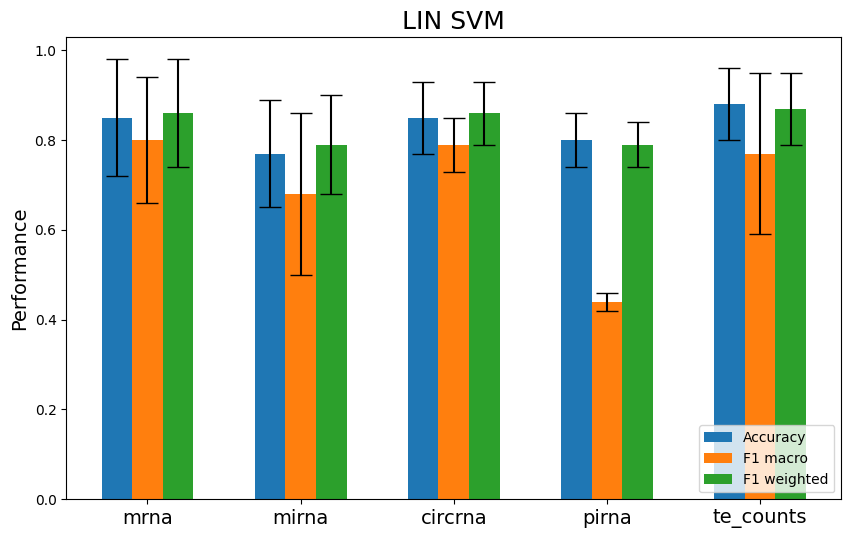

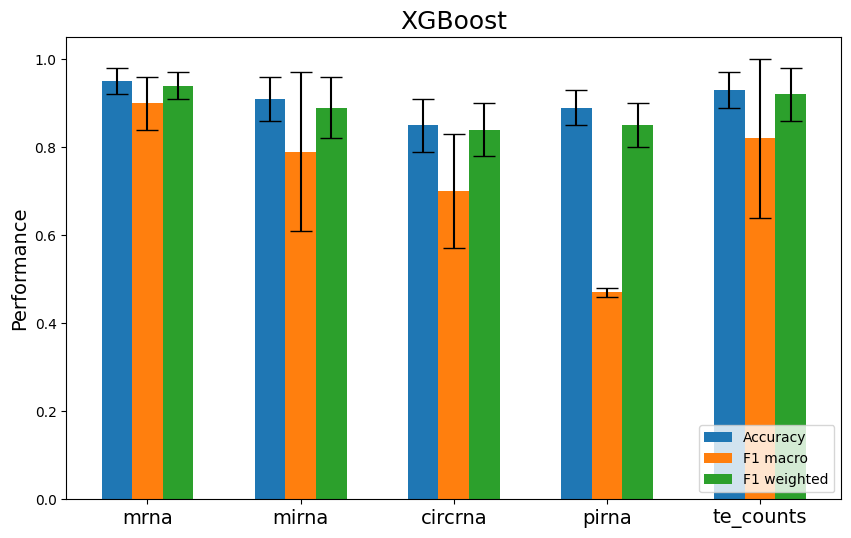

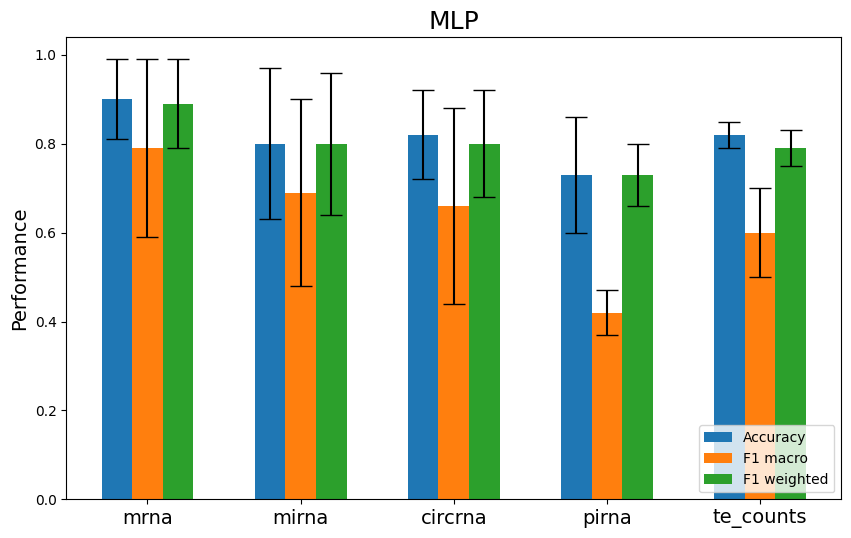

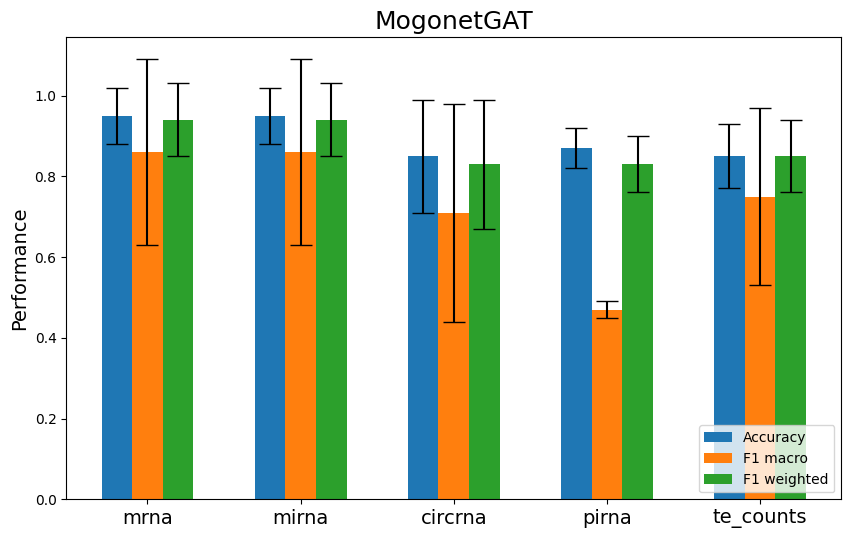

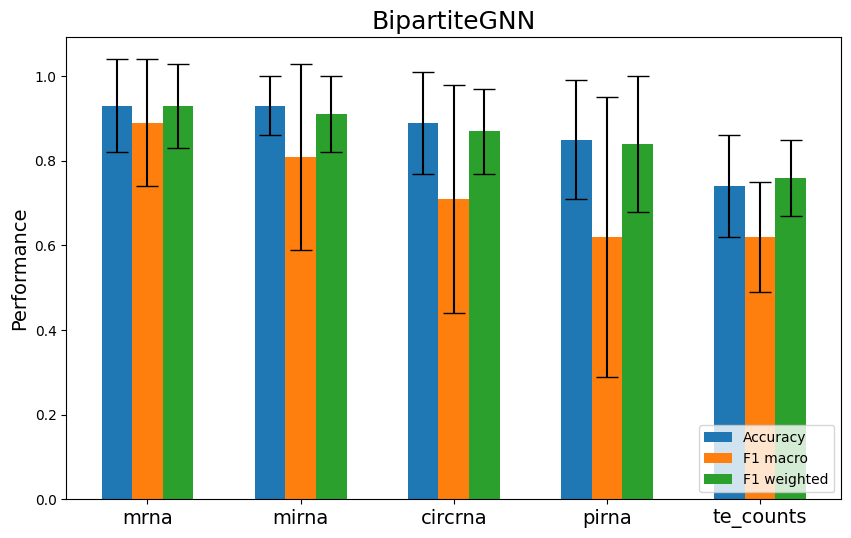

In [48]:
from tkinter import font
import matplotlib.pyplot as plt
import numpy as np

models = ['KNN', 'LIN SVM', 'XGBoost', 'MLP', 'MogonetGAT', 'BipartiteGNN']

# ACC
acc_mrna = [0.89, 0.85, 0.95, 0.90, 0.95, 0.93]
acc_mirna = [0.88, 0.77, 0.91, 0.80, 0.95, 0.93]
acc_circrna = [0.84, 0.85, 0.85, 0.82, 0.85, 0.89]
acc_pirna = [0.89, 0.80, 0.89, 0.73, 0.87, 0.85]
acc_te_counts = [0.87, 0.88, 0.93, 0.82, 0.85, 0.74]

# F1 macro
f1_macro_mrna = [0.75, 0.80, 0.90, 0.79, 0.86, 0.89]
f1_macro_mirna = [0.70, 0.68, 0.79, 0.69, 0.86, 0.81]
f1_macro_circrna = [0.65, 0.79, 0.70, 0.66, 0.71, 0.71]
f1_macro_pirna = [0.47, 0.44, 0.47, 0.42, 0.47, 0.62]
f1_macro_te_counts = [0.77, 0.77, 0.82, 0.60, 0.75, 0.62]

# F1 weighted
f1_weighted_mrna = [0.88, 0.86, 0.94, 0.89, 0.94, 0.93]
f1_weighted_mirna = [0.85, 0.79, 0.89, 0.80, 0.94, 0.91]
f1_weighted_circrna = [0.82, 0.86, 0.84, 0.80, 0.83, 0.87]
f1_weighted_pirna = [0.85, 0.79, 0.85, 0.73, 0.83, 0.84]
f1_weighted_te_counts = [0.86, 0.87, 0.92, 0.79, 0.85, 0.76]

# Standard deviations for ACC
acc_std_mrna = [0.11, 0.13, 0.03, 0.09, 0.07, 0.11]
acc_std_mirna = [0.02, 0.12, 0.05, 0.17, 0.07, 0.07]
acc_std_circrna = [0.05, 0.08, 0.06, 0.10, 0.14, 0.12]
acc_std_pirna = [0.04, 0.06, 0.04, 0.13, 0.05, 0.14]
acc_std_te_counts = [0.09, 0.08, 0.04, 0.03, 0.08, 0.12]

# Standard deviations for F1 macro
f1_macro_std_mrna = [0.26, 0.14, 0.06, 0.20, 0.23, 0.15]
f1_macro_std_mirna = [0.12, 0.18, 0.18, 0.21, 0.23, 0.22]
f1_macro_std_circrna = [0.11, 0.06, 0.13, 0.22, 0.27, 0.27]
f1_macro_std_pirna = [0.01, 0.02, 0.01, 0.05, 0.02, 0.33]
f1_macro_std_te_counts = [0.15, 0.18, 0.18, 0.10, 0.22, 0.13]

# Standard deviations for F1 weighted
f1_weighted_std_mrna = [0.13, 0.12, 0.03, 0.10, 0.09, 0.10]
f1_weighted_std_mirna = [0.04, 0.11, 0.07, 0.16, 0.09, 0.09]
f1_weighted_std_circrna = [0.05, 0.07, 0.06, 0.12, 0.16, 0.10]
f1_weighted_std_pirna = [0.05, 0.05, 0.05, 0.07, 0.07, 0.16]
f1_weighted_std_te_counts = [0.10, 0.08, 0.06, 0.04, 0.09, 0.09]

x = np.arange(len(['mrna', 'mirna', 'circrna', 'pirna', 'te_counts']))
x_labels = ['mrna', 'mirna', 'circrna', 'pirna', 'te_counts']
bar_width = 0.2  # Adjust the width of the bars

for i, model in enumerate(models):
    fig, ax = plt.subplots(figsize=(10, 6))

    # ACC
    acc_values = [acc_mrna[i], acc_mirna[i], acc_circrna[i], acc_pirna[i], acc_te_counts[i]]
    acc_stds = [acc_std_mrna[i], acc_std_mirna[i], acc_std_circrna[i], acc_std_pirna[i], acc_std_te_counts[i]]

    # F1 macro
    f1_macro_values = [f1_macro_mrna[i], f1_macro_mirna[i], f1_macro_circrna[i], f1_macro_pirna[i], f1_macro_te_counts[i]]
    f1_macro_stds = [f1_macro_std_mrna[i], f1_macro_std_mirna[i], f1_macro_std_circrna[i], f1_macro_std_pirna[i], f1_macro_std_te_counts[i]]

    # F1 weighted
    f1_weighted_values = [f1_weighted_mrna[i], f1_weighted_mirna[i], f1_weighted_circrna[i], f1_weighted_pirna[i], f1_weighted_te_counts[i]]
    f1_weighted_stds = [f1_weighted_std_mrna[i], f1_weighted_std_mirna[i], f1_weighted_std_circrna[i], f1_weighted_std_pirna[i], f1_weighted_std_te_counts[i]]

    ax.bar(x - bar_width, acc_values, width=bar_width, yerr=acc_stds, capsize=8, label='Accuracy')
    ax.bar(x, f1_macro_values, width=bar_width, yerr=f1_macro_stds, capsize=8, label='F1 macro')
    ax.bar(x + bar_width, f1_weighted_values, width=bar_width, yerr=f1_weighted_stds, capsize=8, label='F1 weighted')

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=14)
    ax.set_ylabel('Performance', fontsize=14)
    ax.set_title(f'{model}', fontsize=18)
    ax.legend(loc='lower right')
    plt.show()